# Preliminary Model Benchmark Visualization

This notebook visualizes benchmark outputs from `eval/run_models_bench.py`.
It expects `eval/bench_results.csv` to exist.

## run benchmark

In [8]:
!cd ../ && python eval/run_models_bench.py

ℹ️  llama-server binary not found — using llama_cpp.server Python fallback.
Config file: eval\eval_config.txt
Prompts loaded: 10
Repetitions: 2, Warmup prompts: 1
[skip] Missing model file: models\qwen3_5-4b-q8_0.gguf
[skip] Missing model file: models\qwen3_5-4b-q6_K.gguf
[skip] Missing model file: models\qwen3_5-4b-q5_K_M.gguf

== Benchmarking: models\qwen3_5-4b-q4_K_M.gguf (port 8088) ==
  VRAM baseline: 1.23 GB (idle)
  GPU layers: -1  ctx: 4096  threads: -1
  Waiting for server on port 8088 (timeout 120s)... ready!
Server ready. Log: logs\eval\server_qwen3_5-4b-q4_K_M_1777989806.log
  warmup 1/1 complete
  rep=1 prompt=1: TTFT=28.55 ms, TPOT(chunk)=14.33 ms, RSS_peak=3.17 GB, VRAM_peak=3.34 GB, GPU=0
  rep=1 prompt=2: TTFT=33.02 ms, TPOT(chunk)=14.12 ms, RSS_peak=3.18 GB, VRAM_peak=3.33 GB, GPU=0
  rep=1 prompt=3: TTFT=34.58 ms, TPOT(chunk)=14.08 ms, RSS_peak=3.19 GB, VRAM_peak=3.31 GB, GPU=0
  rep=1 prompt=4: TTFT=31.26 ms, TPOT(chunk)=14.23 ms, RSS_peak=3.20 GB, VRAM_peak=3.31 GB

## visualization

## measured columns (what each means)

- `model_file`: GGUF filename being benchmarked.
- `model_path`: workspace-relative path to the GGUF file (not absolute).
- `repetition`: repeat index for the same prompt/model pair.
- `prompt_index`: 1-based index of the prompt in the loaded prompt list.
- `prompt_preview`: first ~120 chars of the prompt for quick inspection.
- `ttft_ms`: Time To First Token in milliseconds.
- `tpot_ms_per_chunk`: average milliseconds between streamed chunks after first token.
- `tpot_ms_per_word`: average milliseconds per generated word after first token.
- `e2e_latency_ms`: total request latency from send to final token.
- `output_chars`: generated output size in characters.
- `output_words`: generated output size in words.
- `chunks_seen`: number of streamed chunks received.
- `peak_rss_gb`: peak process resident memory (RAM) in GB while serving request.
- `peak_vram_gb`: peak total VRAM used by the serving process across all GPUs in GB.
- `gpu_indices`: GPU index(es) used (joined with `|` when multiple).
- `gpu_names`: GPU model name(s) used.
- `gpu_uuids`: GPU UUID(s) used.
- `peak_vram_by_gpu_json`: JSON map of per-GPU peak VRAM in GB.
- `temperature`, `n_predict`, `ctx_size`: generation settings used for that row.

In [9]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

csv_path = Path('./bench_results.csv')
if not csv_path.exists():
    raise FileNotFoundError(f'Missing benchmark CSV: {csv_path}. Run eval/run_models_bench.py first.')

df = pd.read_csv(csv_path)
df.head()

,model_path,model_file,repetition,prompt_index,prompt_preview,ttft_ms,tpot_ms_per_chunk,tpot_ms_per_word,e2e_latency_ms,output_chars,...,chunks_seen,peak_rss_gb,peak_vram_gb,gpu_indices,gpu_names,gpu_uuids,peak_vram_by_gpu_json,temperature,n_predict,ctx_size
0,models\qwen3_5-4b-q4_K_M.gguf,qwen3_5-4b-q4_K_M.gguf,1,1,What is gradient descent and how does it work?,28.5519,14.326169,20.912914,1999.4363,541,...,128,3.169746,3.338867,0,NVIDIA GeForce RTX 3070,GPU-15f6196c-5e04-21e5-7c45-09904006efbd,"{""0"": 3.3388671875}",0.1,128,4096
1,models\qwen3_5-4b-q4_K_M.gguf,qwen3_5-4b-q4_K_M.gguf,1,2,What is the difference between supervised and ...,33.0201,14.117998,17.076055,2004.9560,698,...,128,3.179504,3.325195,0,NVIDIA GeForce RTX 3070,GPU-15f6196c-5e04-21e5-7c45-09904006efbd,"{""0"": 3.3251953125}",0.1,128,4096
2,models\qwen3_5-4b-q4_K_M.gguf,qwen3_5-4b-q4_K_M.gguf,1,3,What is overfitting and how can it be mitigated?,34.5831,14.077166,17.527452,1866.7038,645,...,128,3.191040,3.310547,0,NVIDIA GeForce RTX 3070,GPU-15f6196c-5e04-21e5-7c45-09904006efbd,"{""0"": 3.310546875}",0.1,128,4096
3,models\qwen3_5-4b-q4_K_M.gguf,qwen3_5-4b-q4_K_M.gguf,1,4,Explain the bias-variance tradeoff.,31.2568,14.228448,17.543815,1883.2135,672,...,128,3.199612,3.310547,0,NVIDIA GeForce RTX 3070,GPU-15f6196c-5e04-21e5-7c45-09904006efbd,"{""0"": 3.310546875}",0.1,128,4096
4,models\qwen3_5-4b-q4_K_M.gguf,qwen3_5-4b-q4_K_M.gguf,1,5,What is the softmax function used for?,36.2725,14.257194,19.059617,2022.9732,598,...,128,3.205582,3.310547,0,NVIDIA GeForce RTX 3070,GPU-15f6196c-5e04-21e5-7c45-09904006efbd,"{""0"": 3.310546875}",0.1,128,4096


In [10]:
numeric_cols = [
    'ttft_ms',
    'tpot_ms_per_chunk',
    'tpot_ms_per_word',
    'peak_rss_gb',
    'peak_vram_gb',
    'e2e_latency_ms',
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

summary = (
    df.groupby('model_file', dropna=False)
      .agg(
          samples=('model_file', 'count'),
          ttft_ms_mean=('ttft_ms', 'mean'),
          ttft_ms_p95=('ttft_ms', lambda s: s.quantile(0.95)),
          tpot_chunk_mean=('tpot_ms_per_chunk', 'mean'),
          tpot_chunk_p95=('tpot_ms_per_chunk', lambda s: s.quantile(0.95)),
          peak_rss_gb_max=('peak_rss_gb', 'max'),
          peak_vram_gb_max=('peak_vram_gb', 'max'),
      )
      .sort_values('ttft_ms_mean')
      .reset_index()
)
summary

,model_file,samples,ttft_ms_mean,ttft_ms_p95,tpot_chunk_mean,tpot_chunk_p95,peak_rss_gb_max,peak_vram_gb_max
0,qwen3_5-4b-q4_K_M.gguf,20,32.716365,36.9977,13.964801,14.368614,3.243973,3.341797


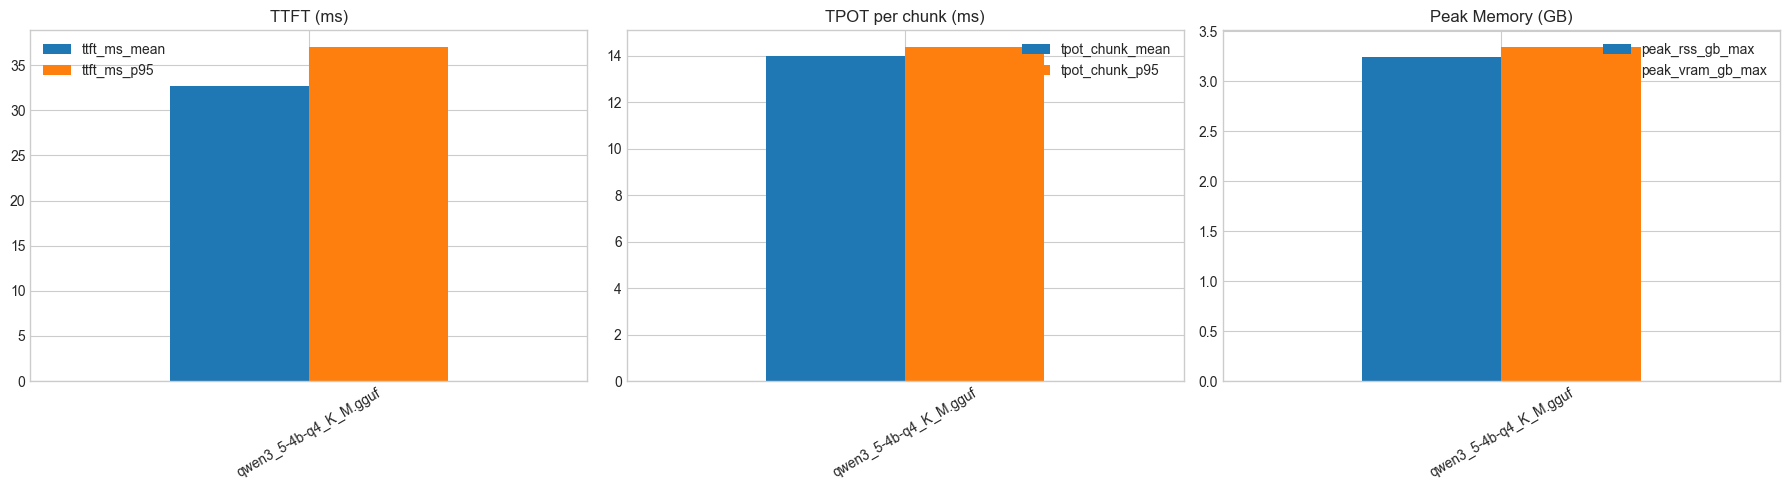

In [11]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

summary.plot(
    x='model_file',
    y=['ttft_ms_mean', 'ttft_ms_p95'],
    kind='bar',
    ax=axes[0],
    title='TTFT (ms)',
)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

summary.plot(
    x='model_file',
    y=['tpot_chunk_mean', 'tpot_chunk_p95'],
    kind='bar',
    ax=axes[1],
    title='TPOT per chunk (ms)',
)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

summary.plot(
    x='model_file',
    y=['peak_rss_gb_max', 'peak_vram_gb_max'],
    kind='bar',
    ax=axes[2],
    title='Peak Memory (GB)',
)
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

,gpu_index,samples
0,0,20


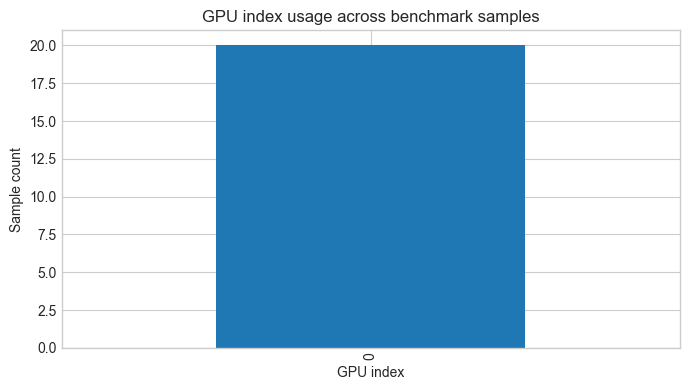

In [12]:
if 'gpu_indices' in df.columns:
    gpu_counts = (
        df['gpu_indices']
          .fillna('unknown')
          .astype(str)
          .str.split('|')
          .explode()
          .str.strip()
          .replace('', 'unknown')
          .value_counts()
          .rename_axis('gpu_index')
          .reset_index(name='samples')
    )

    display(gpu_counts)

    ax = gpu_counts.plot(
        x='gpu_index',
        y='samples',
        kind='bar',
        figsize=(7, 4),
        legend=False,
        title='GPU index usage across benchmark samples',
    )
    ax.set_xlabel('GPU index')
    ax.set_ylabel('Sample count')
    plt.tight_layout()
    plt.show()
else:
    print('No GPU columns found in CSV. Re-run eval/run_models_bench.py with latest version.')